# 합성곱 신경망 맛보기

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
train_dataset = torchvision.datasets.FashionMNIST('/content/drive/MyDrive/ESAA/OB', download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST('/content/drive/MyDrive/ESAA/OB', download=True, transform=transforms.Compose([transforms.ToTensor()]))

In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

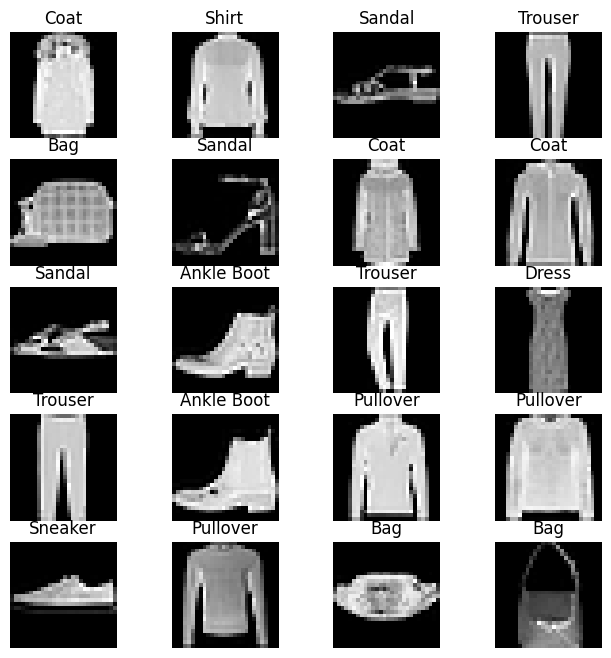

In [5]:
labels_map = {0:'T-Shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'}

fig = plt.figure(figsize=(8,8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
  img_xy = np.random.randint(len(train_dataset)) # 0~train_dataset길이 값을 갖는 분포에서 랜덤한 숫자 한 개 생성.
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

## 심층 신경망 모델 생성
 클래스(class) 형태의 모델은 항상 torch.nn.Module을 상속받습니다. __ init __ ()은 객체가 갖
는 속성 값을 초기화하는 역할을 하며 객체가 생성될 때 자동으로 호출됩니다. super( FashionDNN,
self). __ init __ ()은 nn.Module 클래스를 상속받겠다는 의미로 이해하면 됩니다.

 C++에
서 사용하는 객체 지항 프로그램의 특징들을 파이토치에서도 사용하게 되는데， 대표적인 것이 객체라는 개념입니다.
객체 지항 프로그래밍(object oriented programming)
은 프로그래밍에서 필요한 데이터를 추상화하여 속성이나
행동， 동작， 특징 등을 객체로 만들고， 그 객체들이 서로 유
기적으로 동작하도록 하는 프로그래밍 방법입니다. 좀 더
쉽게 표현하면 클래스라는 붕어빵 틀에서 여러 개의 객체
라는 붕어빵을 찍어 내는 것과 같습니다. 즉， 재사용성의
이유로 객체 지항 프로그래밍을 많이 사용하고 있습니다.

In [6]:
# import numpy as np
# np.random.randint(10)
# np.random.randint(1,10)
# np.random.rand(8)
# np.random.rand(4,2)
# np.random.rand(8)
# np.random.randn(4,2)

In [7]:
# import numpy as np
# examp = np.arange(0,100,3)
# examp.resize(6,4)
# examp
# examp[3]
# examp[3,3]
# examp[3][3]
# examp = np.arange(0,500,3)
# examp.resize(3,5,5)
# examp
# examp[2][0][3]

In [8]:
# ConvNet이 적용되지 않은 네트워크
class FashionDNN(nn.Module): # class형태의 모델은 항상 torch.nn.Module을 상속받음.
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256) # nn은 딥러닝 모델 구성에 필요한 모듈이 모인 패키지.                   (은닉층 1): 입력층과 완전연결
    self.drop = nn.Dropout(0.25) # p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않은 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐.
    self.fc2 = nn.Linear(in_features=256, out_features=128) # (은닉층 2): fc1과 완전연결
    self.fc3 = nn.Linear(in_features=128, out_features=10)  # (출력층): fc2와 완전연결

  def forward(self, input_data): # 순전파 학습 진행.
    out = input_data.view(-1,784) # input(?, 784)의 크기로 변경
    out = F.relu(self.fc1(out)) # 활성화함수
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

In [9]:
# import torch
# import torch.nn as nn

# inputs = torch.randn(64, 3, 244, 244)
# conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
# outputs = conv(inputs)
# layer = nn.Conv2d(1,2,3)

In [11]:
# import torch.nn.functional as F

# inputs = torch.randn(64, 3, 244, 244)
# weights = torch.randn(64, 3, 3, 3)
# bias = torch.randn(64)
# outputs = F.conv2d(inputs, weights, bias, padding=1)

## 심층 신경망에서 필요한 따라미터 정의
옵티마이저를 위한 경사 하강법은 Adam을 사용하며 학습률을 의미히는 lr은 0.001을 사용
한다는의미입니다.



In [12]:
# DNN에서 필요한 파라미터 정의
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss() # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
# DNN을 이용한 모델 학습
num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader: # 레코드(행, 가로줄)를 하나씩 가져옴. 레코드에서 요소 두 개를 꺼내 오겠다는 의미.
    images, labels = images.to(device), labels.to(device) # 모델과 데이터가 동일한 장치에 있도록.

    train = Variable(images.view(100,1,28,28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50): # count를 50으로 나눴을 때 나머지가 0이 아니면 실행
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count%500):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5918362736701965, Accuracy: 84.36333465576172%
Iteration: 1000, Loss: 0.4093579351902008, Accuracy: 86.12000274658203%
Iteration: 1500, Loss: 0.3481290340423584, Accuracy: 86.75666809082031%
Iteration: 2000, Loss: 0.36494672298431396, Accuracy: 87.27833557128906%
Iteration: 2500, Loss: 0.25264933705329895, Accuracy: 87.97333526611328%
Iteration: 3000, Loss: 0.2700483798980713, Accuracy: 88.75499725341797%


이제 심층신경망에 데이터를적용하여 모댈을학습시겁니다.

모댈이 데이터를 처리하기 위해서는 모댈과 데이터가 동일한 장치(CPU 또는 GPU)에 있어야
합니다. 코드 5-7에서 model. to(device)가 GPU를 사용했다면 images.to(device), labels
to(device)도 GPU에서 처리되어야 합니다. 참고로 CPU에서 처리된 데이터를 GPU 모벨에 적
용하거나 그 반대의 경우 런타임 오류가 발생합니다.


Autograd는 자동 미분을 수행하는 파이토치의 핵심 패키지로， 자동 미분에 대한 값을 저장하
기 위해 테이프(tape)를 사용합니다. 순전파(fO\vard) 단계에서 태이프는 수행하는 모든 연산을 저
장합니다. 그리고 역전파(backward) 단계에서 저장된 값들을 꺼내서 사용합니다. 즉， Autograd는
Variable을 사용해서 역전파를 위한 미분 값을 자동으로 계산해 줍니다. 따라서 자동 미분을 계
산하기 위해서는 torch.autograd 패키지 안에 있는 Variable을 이용해야 동작합니다.

분류 문제에 대한 정확도는 전체 에측에 대한 정확한 예측의 비율로 표현할 수 있으며， 코드는
다음과같습니다.
classification accuracy = correct predictions / total predictions
이때 결과에 100을곱하여 백분율로표시하는코드는다음과같습니다.
classification accuracy = correct predictions / total predictions * 100
또한， 분류문제에 대한정확도는다음과같이 값을반전시켜 오분류율또는오류율로표현할수
있습니다.

error rate = (1 - (correct predictions / total predictions)) * 100

분류 문제에서 클래스가 세 개 이상일 때는 다음과 같은 사항에 주의해야 합니다.
* 정확도가80% 이상이었다고합시다. 하지만80%라는값이 모든 클래스가 동등하게 고려된 것인지， 특정 클래스의 분류가높았던 것인지에 대해 알수 없음에 유의해야합니다.
* 정확도가 90% 이상이었다고 합시다. 하지만 100개의 데이터 중 90개가 하나의 클래스에 속할 경우 90%의 정확도는 높다고 할 수 없습니다. 즉， 모든 데이터를 특정 클래스에 속한다고 예측해도 90%의 예측 결과가 나오기 때문에 데이터 특성에 따라 정확도를 잘 관측해야합니다.

In [14]:
# CNN 네트웤 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential( # nn.Sequential은 계층을 차례로 쌓을 수 있도록 수식과 활성화 함수를 연결.
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32), # 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 정규화하는 것.
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2) # 이미지 크기 축소.
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1) # (100,?)로 변환.
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

 nn.Sequential을 사용하면 __ ini t __ ()에서 사용할 네트워크 모댈들을 정의해 줄 뿐만 아니
라， forward() 함수에서 구현될 순전피를 계층(laycr) 형태로 좀 더 가독성이 뛰어난 코드로 작성
할 수 있습니다. 즉 nn.Sequential은 계층을 차례로 쌓을 수 있도록 Wx+ b와 같은 수식과 활성
화 함수를 연결해 주는 역할을 합니다. 특히 데이터가 각 계층을 순차적으로 지나갈 때 사용하면
좋은 방법입니다. 정리하면 nn.Sequential은 여러 개의 계층을 하나의 컨테이너에 구현하는 방법
이라고 생각하면 됩니다.

합성곱층(ωnv Jaycr)은 합성곱 연산을 통해서 이미지의 특정을 추출합니다. 합성곱이란 커널(또
는 필터)이라는 n Xm 크기의 행렬이 높이(bcigbt) X 너비(\\띠h) 크기의 이미지를 처음부터 끝까지
훌으면서 각원소값끼리 곱한후모두 더한값을출력합니다.

in_channels: 입력 채널의 수를 의미합니다. 흑백 이미지는 1. RGB 값을 가진 이미지는
3을 가진 경우가 많습니다.
그렇다면 채널은 무엇일까요?
2D 합성곱층에 이미지를 적용한다고 가정해 봅시다. 흑백 이미지일 경우 이미지 데이터는
w xh 형태의 행렬로 표현됩니다(이때 w는 이미지의 너비， h는 이미지의 높이가 됩니다). 이
번에는 컬러 이미지를 가정해 봅시다. 컬러 이미지는 일반적으로 Red, Green, Blue라는 세
개의 채널을 가지고 있습니다. 이때 컬러 이미지는 wxhxc 형태의 행렬로 표현될 수 있습니다. C는 채널 수를 의미합니다. 3차원으로 생각하면 채널은 결국 갚이(depth)를 의미한다고 할 수있습니다.

BatchN orm2d는 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균
과 분산을 이용하여 정규화하는 것을 의미합니다. 다음 그림을 보면 배치 단위나 계층에 따라 입
력 값의 분포가 모두 다르지만 정규화를 통해 분포를 가우시안 형태로 만듭니다. 그러면 평균은
0, 표준편치는 1로 데이터의 분포가 조정됩니다.

클래스를 분류하기 위해서는 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야 합니다.
이때 Conv2d에서 사용하는 하이퍼파라미터 값들에 따라 출력이 달라집니다.
즉， 패딩과 스트라이드의 값에 따라 출력 크기가 달라집니다. 이렇게 줄어든 출력 크기는 최종적
으로 분류를 담당히는 완전연결층(fully connccred laycr)으로 전달됩니다.


 in_features: 입력 데이터의 크기를 의미합니다. 중요한 것은 이전까지 수행했던 Conv2d,
MaxPoo12d는 이미지 데이터를 입력으로 받아 처리했습니다.

In [15]:
# 합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001
model = FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [ ]:
# 모델 학습 및 성능 평가
num_epochs = 5
count = 0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100,1,28,28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.476954847574234, Accuracy: 88.44666290283203%
Iteration: 1000, Loss: 0.33206793665885925, Accuracy: 88.83833312988281%
Iteration: 1500, Loss: 0.3748934864997864, Accuracy: 88.27666473388672%
Iteration: 2000, Loss: 0.1750124990940094, Accuracy: 91.92166900634766%
Iteration: 2500, Loss: 0.14032170176506042, Accuracy: 91.78333282470703%
Iteration: 3000, Loss: 0.19632470607757568, Accuracy: 92.80000305175781%


심층 신경망과 비교하여 정확도가 약간 높습나다. 심층 신경망과 별 차이가 없기 때문에 좀 더 간
편한 심층 신경망만 사용해도 무난할 것 같지만 실제로 이미지 데이터가 많아지면 단순 심층 신경
망으로는 정확한 특성 추출 및 분류가 불기능하므로 합성곱 신경망을 생성할 수 있도록 학습해야
합니다.